# AirPanel Question Wrongness Metrics

This notebook asks: when a question or dimension points away from the final output, how wrong is it?


## Inputs

We use the per-question score dataset and the respondent-level final preference scores.


In [14]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="paper", font_scale=1.0)

PROJECT_DIR = Path("/Users/martateodoratrales/Documents/New project")
QUESTION_SCORE_PATH = Path("/Users/martateodoratrales/Downloads/interviews_with_question_scores_mistral_7b_t4_full.csv")
RESPONDENT_METRICS_PATH = PROJECT_DIR / "airpanel_metric_outputs" / "respondent_construct_metrics.csv"
OUTPUT_DIR = PROJECT_DIR / "airpanel_wrongness_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

print(QUESTION_SCORE_PATH)
print(RESPONDENT_METRICS_PATH)
print(OUTPUT_DIR)


/Users/martateodoratrales/Downloads/interviews_with_question_scores_mistral_7b_t4_full.csv
/Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/respondent_construct_metrics.csv
/Users/martateodoratrales/Documents/New project/airpanel_wrongness_outputs


In [15]:
wide = pd.read_csv(QUESTION_SCORE_PATH)
respondent = pd.read_csv(RESPONDENT_METRICS_PATH)

target_cols = ["panelist_id", "overall_bouygues", "overall_orange", "overall_diff", "resolved_preference", "pref_bouygues_binary"]
target = respondent[target_cols].copy()
df = wide.merge(target, on="panelist_id", how="inner")

print(df.shape)
print(df["panelist_id"].nunique())
display(df["resolved_preference"].value_counts(dropna=False).rename_axis("resolved_preference").reset_index(name="n"))


(800, 383)
800


,resolved_preference,n
0,orange,594
1,bouygues,169
2,tie,37


## Metric

For each respondent, question, and dimension, we compare the question-level signed score to the final overall difference.


In [16]:
dimensions = ["creativity", "humour", "originality", "reliability_trust", "intent_to_purchase", "overall"]
question_ids = sorted(
    {
        match.group(1)
        for col in df.columns
        for match in [re.match(r"creativity_(q\d+)_bouygues$", col)]
        if match
    },
    key=lambda x: int(x[1:])
)

rows = []
for qid in question_ids:
    q_name_col = f"question_column_{qid}"
    q_name = df[q_name_col].dropna().iloc[0] if q_name_col in df.columns and df[q_name_col].notna().any() else qid
    confidence_col = f"confidence_{qid}"
    confidence = df[confidence_col].mean() if confidence_col in df.columns else np.nan
    for dimension in dimensions:
        b_col = f"{dimension}_{qid}_bouygues"
        o_col = f"{dimension}_{qid}_orange"
        if b_col not in df.columns or o_col not in df.columns:
            continue
        tmp = df[["panelist_id", "overall_bouygues", "overall_orange", "overall_diff", "resolved_preference", b_col, o_col]].copy()
        tmp["question_id"] = qid
        tmp["question_column"] = q_name
        tmp["dimension"] = dimension
        tmp["score_bouygues"] = tmp[b_col]
        tmp["score_orange"] = tmp[o_col]
        tmp["question_diff"] = tmp[b_col] - tmp[o_col]
        tmp["target_diff"] = tmp["overall_diff"]
        tmp["question_sign"] = np.sign(tmp["question_diff"])
        tmp["target_sign"] = np.sign(tmp["target_diff"])
        tmp["distance_to_output"] = (tmp["question_diff"] - tmp["target_diff"]).abs()
        tmp["wrong_direction"] = tmp["question_sign"].mul(tmp["target_sign"]).lt(0)
        tmp["no_question_signal"] = tmp["question_sign"].eq(0)
        tmp["aligned_direction"] = tmp["question_sign"].eq(tmp["target_sign"])
        tmp["direction_loss"] = np.select([tmp["wrong_direction"], tmp["no_question_signal"]], [1.0, 0.5], default=0.0)
        tmp["wrong_amount"] = np.maximum(0, -tmp["target_sign"] * tmp["question_diff"])
        tmp["regret"] = np.select([tmp["wrong_direction"], tmp["no_question_signal"]], [tmp["target_diff"].abs(), 0.5 * tmp["target_diff"].abs()], default=0.0)
        tmp["margin_adjusted_wrongness"] = tmp["wrong_amount"] / np.maximum(tmp["target_diff"].abs(), 1)
        tmp["question_confidence_mean"] = confidence
        rows.append(tmp[["panelist_id", "question_id", "question_column", "dimension", "resolved_preference", "overall_bouygues", "overall_orange", "score_bouygues", "score_orange", "question_diff", "target_diff", "question_sign", "target_sign", "distance_to_output", "wrong_direction", "no_question_signal", "aligned_direction", "direction_loss", "wrong_amount", "regret", "margin_adjusted_wrongness", "question_confidence_mean"]])

long = pd.concat(rows, ignore_index=True)
long = long[long["target_sign"].ne(0)].dropna(subset=["question_diff", "target_diff"])

print(long.shape)
display(long.head())
long.to_csv(TABLE_DIR / "wrongness_long_table.csv", index=False)


(100716, 22)


,panelist_id,question_id,question_column,dimension,resolved_preference,overall_bouygues,overall_orange,score_bouygues,score_orange,question_diff,...,target_sign,distance_to_output,wrong_direction,no_question_signal,aligned_direction,direction_loss,wrong_amount,regret,margin_adjusted_wrongness,question_confidence_mean
2,67b0d12bd362f5886c2e5b09,q1,Q_bouygues_reactions_spontanees_1,creativity,orange,7,8,0,0,0,...,-1,1,False,True,False,0.5,0,0.5,0.0,0.016313
3,67b0d127d362f5886c2e5a4a,q1,Q_bouygues_reactions_spontanees_1,creativity,orange,4,8,0,0,0,...,-1,4,False,True,False,0.5,0,2.0,0.0,0.016313
5,67b0d127d362f5886c2e5a5b,q1,Q_bouygues_reactions_spontanees_1,creativity,orange,6,8,0,0,0,...,-1,2,False,True,False,0.5,0,1.0,0.0,0.016313
6,67b0d129d362f5886c2e5aa6,q1,Q_bouygues_reactions_spontanees_1,creativity,bouygues,7,5,0,0,0,...,1,2,False,True,False,0.5,0,1.0,0.0,0.016313
7,67b0d128d362f5886c2e5aa0,q1,Q_bouygues_reactions_spontanees_1,creativity,orange,6,7,0,0,0,...,-1,1,False,True,False,0.5,0,0.5,0.0,0.016313


## Question-dimension wrongness

`E_false` means how far wrong cases are. `E_global` combines wrong frequency and wrong severity.


In [17]:
def question_block(name):
    if str(name).startswith("Q_bouygues"):
        return "bouygues_specific"
    if str(name).startswith("Q_orange"):
        return "orange_specific"
    if str(name).startswith("Q_comparaison"):
        return "comparison"
    return "unknown"


summary_rows = []
for keys, group in long.groupby(["question_id", "question_column", "dimension"], dropna=False):
    qid, qcol, dimension = keys
    wrong = group["wrong_direction"]
    wrong_distances = group.loc[wrong, "distance_to_output"]
    e_false = wrong_distances.mean() if len(wrong_distances) else 0.0
    wrong_rate = wrong.mean()
    e_global = (group["distance_to_output"] * wrong.astype(float)).mean()
    aligned_distance = group.loc[~wrong, "distance_to_output"].mean()
    corr = group[["question_diff", "target_diff"]].corr().iloc[0, 1]
    summary_rows.append(
        {
            "question_id": qid,
            "question_column": qcol,
            "question_block": question_block(qcol),
            "dimension": dimension,
            "n": len(group),
            "wrong_rate": wrong_rate,
            "no_signal_rate": group["no_question_signal"].mean(),
            "direction_loss": group["direction_loss"].mean(),
            "E_false": e_false,
            "E_global": e_global,
            "E_regret": group["regret"].mean(),
            "mean_wrong_amount": group["wrong_amount"].mean(),
            "mean_margin_adjusted_wrongness": group["margin_adjusted_wrongness"].mean(),
            "mean_distance_to_output": group["distance_to_output"].mean(),
            "aligned_distance": aligned_distance,
            "corr_with_output": corr,
            "mean_question_diff": group["question_diff"].mean(),
            "mean_target_diff": group["target_diff"].mean(),
            "question_confidence_mean": group["question_confidence_mean"].mean(),
        }
    )

wrongness = pd.DataFrame(summary_rows)
wrongness["abs_corr_with_output"] = wrongness["corr_with_output"].abs()
wrongness["reliability_index"] = wrongness["abs_corr_with_output"] * (1 - wrongness["wrong_rate"])
wrongness = wrongness.sort_values(["E_global", "wrong_rate"], ascending=False)

wrongness.to_csv(TABLE_DIR / "question_dimension_wrongness.csv", index=False)
display(wrongness.head(12).round(3))


,question_id,question_column,question_block,dimension,n,wrong_rate,no_signal_rate,direction_loss,E_false,E_global,...,mean_wrong_amount,mean_margin_adjusted_wrongness,mean_distance_to_output,aligned_distance,corr_with_output,mean_question_diff,mean_target_diff,question_confidence_mean,abs_corr_with_output,reliability_index
69,q2,Q_bouygues_memorisation_1,bouygues_specific,originality,763,0.113,0.806,0.516,10.151,1.144,...,0.916,0.572,3.626,2.798,0.234,1.590,-1.384,0.187,0.234,0.208
66,q2,Q_bouygues_memorisation_1,bouygues_specific,creativity,763,0.113,0.806,0.516,10.058,1.134,...,0.906,0.570,3.630,2.814,0.245,1.591,-1.384,0.187,0.245,0.217
70,q2,Q_bouygues_memorisation_1,bouygues_specific,overall,763,0.113,0.807,0.516,8.465,0.954,...,0.726,0.456,3.317,2.663,0.242,1.273,-1.384,0.187,0.242,0.215
67,q2,Q_bouygues_memorisation_1,bouygues_specific,humour,763,0.109,0.810,0.514,8.578,0.933,...,0.712,0.449,3.311,2.668,0.252,1.271,-1.384,0.187,0.252,0.224
68,q2,Q_bouygues_memorisation_1,bouygues_specific,intent_to_purchase,763,0.114,0.806,0.517,5.989,0.683,...,0.451,0.288,2.872,2.470,0.260,0.817,-1.384,0.187,0.260,0.230
84,q22,Q_comparaison_6,comparison,creativity,763,0.138,0.634,0.455,4.686,0.645,...,0.397,0.267,2.747,2.438,0.564,1.028,-1.384,0.388,0.564,0.486
71,q2,Q_bouygues_memorisation_1,bouygues_specific,reliability_trust,763,0.114,0.806,0.517,5.287,0.603,...,0.371,0.229,2.688,2.354,0.206,0.612,-1.384,0.187,0.206,0.183
89,q22,Q_comparaison_6,comparison,reliability_trust,763,0.113,0.613,0.419,5.267,0.594,...,0.396,0.315,2.907,2.607,-0.028,-1.347,-1.384,0.388,0.028,0.025
86,q22,Q_comparaison_6,comparison,intent_to_purchase,763,0.115,0.620,0.425,4.580,0.528,...,0.328,0.270,2.954,2.742,0.001,-1.421,-1.384,0.388,0.001,0.001
102,q5,Q_bouygues_attractivite_2,bouygues_specific,creativity,763,0.075,0.896,0.523,6.526,0.488,...,0.345,0.232,2.767,2.463,0.085,0.489,-1.384,0.107,0.085,0.079


## Stability

This checks whether the highest wrongness pairs stay high under panelist resampling.


In [18]:
rng = np.random.default_rng(42)
panelists = long["panelist_id"].drop_duplicates().to_numpy()
top_k = 15
n_bootstrap = 50
key_cols = ["question_id", "question_column", "dimension"]
top_counts = {}

for _ in range(n_bootstrap):
    sampled = pd.DataFrame({"panelist_id": rng.choice(panelists, size=len(panelists), replace=True)})
    boot = sampled.merge(long, on="panelist_id", how="left")
    boot_scores = (
        boot.groupby(key_cols)
        .apply(lambda g: (g["distance_to_output"] * g["wrong_direction"].astype(float)).mean())
        .rename("boot_E_global")
        .reset_index()
        .sort_values("boot_E_global", ascending=False)
        .head(top_k)
    )
    for row in boot_scores[key_cols].itertuples(index=False, name=None):
        top_counts[row] = top_counts.get(row, 0) + 1

stability = pd.DataFrame(
    [{"question_id": k[0], "question_column": k[1], "dimension": k[2], "top15_bootstrap_rate": v / n_bootstrap} for k, v in top_counts.items()]
)
wrongness = wrongness.merge(stability, on=key_cols, how="left")
wrongness["top15_bootstrap_rate"] = wrongness["top15_bootstrap_rate"].fillna(0.0)
wrongness["reliability_label"] = np.select(
    [
        (wrongness["top15_bootstrap_rate"] >= 0.60) & (wrongness["abs_corr_with_output"] >= 0.15),
        (wrongness["top15_bootstrap_rate"] >= 0.25) | (wrongness["abs_corr_with_output"] >= 0.10),
    ],
    ["stable", "follow_up"],
    default="fragile",
)
wrongness = wrongness.sort_values(["E_global", "top15_bootstrap_rate"], ascending=False)
wrongness.to_csv(TABLE_DIR / "question_dimension_wrongness.csv", index=False)
display(wrongness.head(12).round(3))


,question_id,question_column,question_block,dimension,n,wrong_rate,no_signal_rate,direction_loss,E_false,E_global,...,mean_distance_to_output,aligned_distance,corr_with_output,mean_question_diff,mean_target_diff,question_confidence_mean,abs_corr_with_output,reliability_index,top15_bootstrap_rate,reliability_label
0,q2,Q_bouygues_memorisation_1,bouygues_specific,originality,763,0.113,0.806,0.516,10.151,1.144,...,3.626,2.798,0.234,1.590,-1.384,0.187,0.234,0.208,1.00,stable
1,q2,Q_bouygues_memorisation_1,bouygues_specific,creativity,763,0.113,0.806,0.516,10.058,1.134,...,3.630,2.814,0.245,1.591,-1.384,0.187,0.245,0.217,1.00,stable
2,q2,Q_bouygues_memorisation_1,bouygues_specific,overall,763,0.113,0.807,0.516,8.465,0.954,...,3.317,2.663,0.242,1.273,-1.384,0.187,0.242,0.215,1.00,stable
3,q2,Q_bouygues_memorisation_1,bouygues_specific,humour,763,0.109,0.810,0.514,8.578,0.933,...,3.311,2.668,0.252,1.271,-1.384,0.187,0.252,0.224,1.00,stable
4,q2,Q_bouygues_memorisation_1,bouygues_specific,intent_to_purchase,763,0.114,0.806,0.517,5.989,0.683,...,2.872,2.470,0.260,0.817,-1.384,0.187,0.260,0.230,1.00,stable
5,q22,Q_comparaison_6,comparison,creativity,763,0.138,0.634,0.455,4.686,0.645,...,2.747,2.438,0.564,1.028,-1.384,0.388,0.564,0.486,1.00,stable
6,q2,Q_bouygues_memorisation_1,bouygues_specific,reliability_trust,763,0.114,0.806,0.517,5.287,0.603,...,2.688,2.354,0.206,0.612,-1.384,0.187,0.206,0.183,1.00,stable
7,q22,Q_comparaison_6,comparison,reliability_trust,763,0.113,0.613,0.419,5.267,0.594,...,2.907,2.607,-0.028,-1.347,-1.384,0.388,0.028,0.025,0.98,follow_up
8,q22,Q_comparaison_6,comparison,intent_to_purchase,763,0.115,0.620,0.425,4.580,0.528,...,2.954,2.742,0.001,-1.421,-1.384,0.388,0.001,0.001,0.98,follow_up
9,q5,Q_bouygues_attractivite_2,bouygues_specific,creativity,763,0.075,0.896,0.523,6.526,0.488,...,2.767,2.463,0.085,0.489,-1.384,0.107,0.085,0.079,0.90,follow_up


## Most misleading signals

These are the question-dimension pairs with the highest global wrongness.


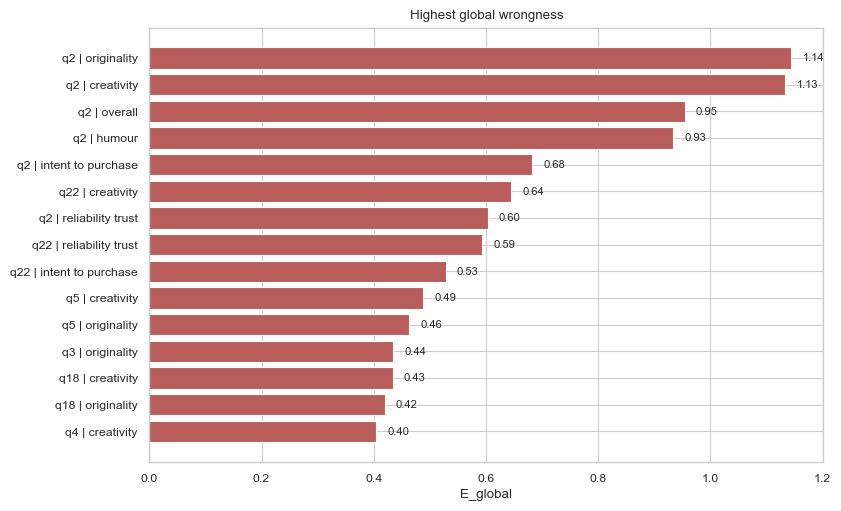

In [19]:
plot_df = wrongness.head(15).copy()
plot_df["label"] = plot_df["question_id"] + " | " + plot_df["dimension"].str.replace("_", " ")
plot_df = plot_df.sort_values("E_global")

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.barh(plot_df["label"], plot_df["E_global"], color="#b85c5c")
ax.set_xlabel("E_global")
ax.set_ylabel("")
ax.set_title("Highest global wrongness")
for y, value in enumerate(plot_df["E_global"]):
    ax.text(value + 0.02, y, f"{value:.2f}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "highest_global_wrongness.png", dpi=300, bbox_inches="tight")
plt.show()


## Most reliable signals

These pairs are aligned with the final output and rarely point in the wrong direction.


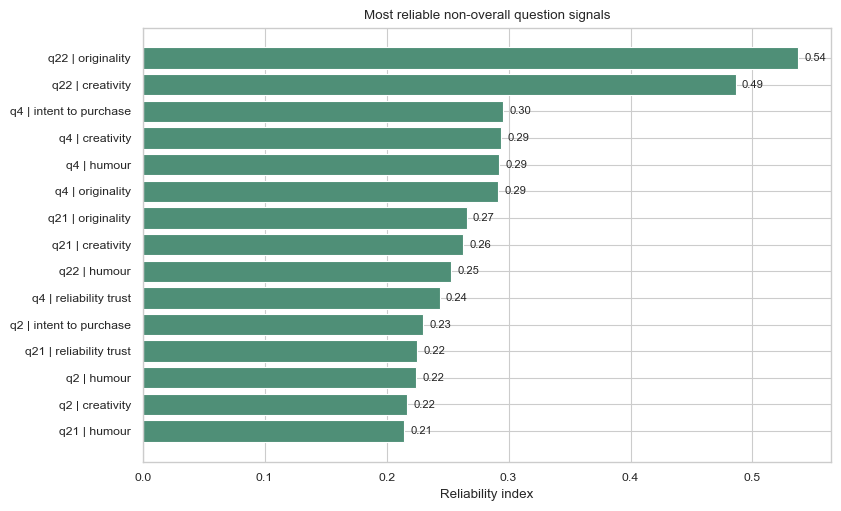

,question_id,question_column,question_block,dimension,wrong_rate,E_false,E_global,corr_with_output,reliability_index
51,q22,Q_comparaison_6,comparison,originality,0.038,3.966,0.151,0.559,0.538
5,q22,Q_comparaison_6,comparison,creativity,0.138,4.686,0.645,0.564,0.486
31,q4,Q_bouygues_attractivite_1,bouygues_specific,intent_to_purchase,0.043,6.788,0.294,0.309,0.296
14,q4,Q_bouygues_attractivite_1,bouygues_specific,creativity,0.043,9.333,0.404,0.307,0.294
23,q4,Q_bouygues_attractivite_1,bouygues_specific,humour,0.038,8.759,0.333,0.304,0.293
18,q4,Q_bouygues_attractivite_1,bouygues_specific,originality,0.043,8.848,0.383,0.305,0.292
65,q21,Q_comparaison_5,comparison,originality,0.017,5.846,0.100,0.270,0.266
50,q21,Q_comparaison_5,comparison,creativity,0.026,5.900,0.155,0.270,0.263
59,q22,Q_comparaison_6,comparison,humour,0.021,5.750,0.121,0.258,0.253
34,q4,Q_bouygues_attractivite_1,bouygues_specific,reliability_trust,0.043,6.455,0.279,0.255,0.244


In [20]:
reliable = wrongness[wrongness["dimension"].ne("overall")].sort_values(["reliability_index", "E_global"], ascending=[False, True]).head(15).copy()
reliable["label"] = reliable["question_id"] + " | " + reliable["dimension"].str.replace("_", " ")
reliable_plot = reliable.sort_values("reliability_index")

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.barh(reliable_plot["label"], reliable_plot["reliability_index"], color="#4f8f77")
ax.set_xlabel("Reliability index")
ax.set_ylabel("")
ax.set_title("Most reliable non-overall question signals")
for y, value in enumerate(reliable_plot["reliability_index"]):
    ax.text(value + 0.005, y, f"{value:.2f}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "most_reliable_question_signals.png", dpi=300, bbox_inches="tight")
plt.show()

display(reliable[["question_id", "question_column", "question_block", "dimension", "wrong_rate", "E_false", "E_global", "corr_with_output", "reliability_index"]].round(3))


## Dimension summary

This shows which dimensions are safest or most misleading on average.


,dimension,n_pairs,mean_wrong_rate,mean_E_false,mean_E_global,median_E_global,mean_abs_corr,mean_reliability_index
0,creativity,22,0.031,6.700,0.223,0.136,0.109,0.102
3,originality,22,0.026,6.800,0.202,0.105,0.109,0.105
4,overall,22,0.027,5.585,0.181,0.107,0.087,0.083
5,reliability_trust,22,0.027,5.976,0.170,0.083,0.080,0.076
2,intent_to_purchase,22,0.028,4.954,0.158,0.084,0.081,0.077
1,humour,22,0.019,6.083,0.141,0.079,0.077,0.074


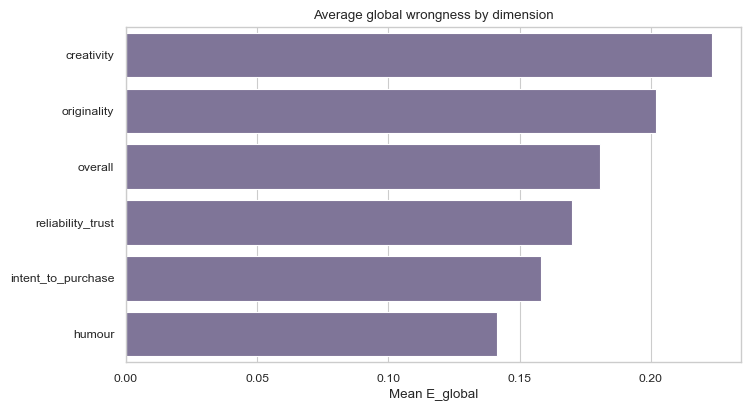

In [21]:
dimension_summary = (
    wrongness.groupby("dimension")
    .agg(
        n_pairs=("question_id", "count"),
        mean_wrong_rate=("wrong_rate", "mean"),
        mean_E_false=("E_false", "mean"),
        mean_E_global=("E_global", "mean"),
        median_E_global=("E_global", "median"),
        mean_abs_corr=("abs_corr_with_output", "mean"),
        mean_reliability_index=("reliability_index", "mean"),
    )
    .reset_index()
    .sort_values("mean_E_global", ascending=False)
)

dimension_summary.to_csv(TABLE_DIR / "dimension_wrongness_summary.csv", index=False)
display(dimension_summary.round(3))

fig, ax = plt.subplots(figsize=(7.6, 4.2))
sns.barplot(data=dimension_summary, y="dimension", x="mean_E_global", color="#7c6f9e", ax=ax)
ax.set_xlabel("Mean E_global")
ax.set_ylabel("")
ax.set_title("Average global wrongness by dimension")
fig.tight_layout()
fig.savefig(FIG_DIR / "dimension_global_wrongness.png", dpi=300, bbox_inches="tight")
plt.show()


## Question block summary

This checks whether comparison questions behave differently from brand-specific questions.


In [22]:
block_summary = (
    wrongness.groupby("question_block")
    .agg(
        n_pairs=("question_id", "count"),
        mean_wrong_rate=("wrong_rate", "mean"),
        mean_E_false=("E_false", "mean"),
        mean_E_global=("E_global", "mean"),
        mean_abs_corr=("abs_corr_with_output", "mean"),
        mean_reliability_index=("reliability_index", "mean"),
    )
    .reset_index()
    .sort_values("mean_E_global", ascending=False)
)

block_summary.to_csv(TABLE_DIR / "question_block_wrongness_summary.csv", index=False)
display(block_summary.round(3))


,question_block,n_pairs,mean_wrong_rate,mean_E_false,mean_E_global,mean_abs_corr,mean_reliability_index
0,bouygues_specific,48,0.041,7.154,0.295,0.128,0.120
1,comparison,36,0.028,5.222,0.154,0.104,0.099
2,orange_specific,48,0.011,5.475,0.082,0.040,0.039


## Ablations

These small checks show whether wrongness is driven by target-proximate dimensions or question blocks.


In [23]:
ablation_specs = {
    "all": wrongness.index == wrongness.index,
    "no_overall": wrongness["dimension"].ne("overall"),
    "no_intent": wrongness["dimension"].ne("intent_to_purchase"),
    "no_overall_no_intent": wrongness["dimension"].ne("overall") & wrongness["dimension"].ne("intent_to_purchase"),
    "creative_only": wrongness["dimension"].isin(["creativity", "humour", "originality"]),
    "commercial_only": wrongness["dimension"].isin(["reliability_trust", "intent_to_purchase"]),
    "comparison_only": wrongness["question_block"].eq("comparison"),
    "no_comparison": wrongness["question_block"].ne("comparison"),
}

ablation_rows = []
for name, mask in ablation_specs.items():
    sub = wrongness.loc[mask].copy()
    if sub.empty:
        continue
    ablation_rows.append(
        {
            "ablation": name,
            "n_pairs": len(sub),
            "mean_wrong_rate": sub["wrong_rate"].mean(),
            "mean_E_false": sub["E_false"].mean(),
            "mean_E_global": sub["E_global"].mean(),
            "top_E_global": sub["E_global"].max(),
            "mean_abs_corr": sub["abs_corr_with_output"].mean(),
            "stable_pair_rate": sub["reliability_label"].eq("stable").mean(),
        }
    )

ablation_summary = pd.DataFrame(ablation_rows).sort_values("mean_E_global", ascending=False)
ablation_summary.to_csv(TABLE_DIR / "wrongness_ablation_summary.csv", index=False)
display(ablation_summary.round(3))


,ablation,n_pairs,mean_wrong_rate,mean_E_false,mean_E_global,top_E_global,mean_abs_corr,stable_pair_rate
4,creative_only,66,0.025,6.528,0.189,1.144,0.098,0.076
7,no_comparison,96,0.026,6.314,0.189,1.144,0.085,0.073
3,no_overall_no_intent,88,0.026,6.390,0.184,1.144,0.094,0.068
2,no_intent,110,0.026,6.229,0.183,1.144,0.092,0.064
0,all,132,0.026,6.016,0.179,1.144,0.090,0.061
1,no_overall,110,0.026,6.103,0.179,1.144,0.091,0.064
5,commercial_only,44,0.028,5.465,0.164,0.683,0.080,0.045
6,comparison_only,36,0.028,5.222,0.154,0.645,0.104,0.028


## Negative control

The signal should weaken when final outputs are shuffled across panelists.


In [24]:
control_map = pd.Series(rng.permutation(target.set_index("panelist_id")["overall_diff"].loc[panelists].to_numpy()), index=panelists)
control = long.copy()
control["control_target_diff"] = control["panelist_id"].map(control_map)
control["control_target_sign"] = np.sign(control["control_target_diff"])
control["control_wrong"] = control["question_sign"].mul(control["control_target_sign"]).lt(0)
control["control_distance"] = (control["question_diff"] - control["control_target_diff"]).abs()

control_summary = (
    control.groupby(["question_id", "question_column", "dimension"])
    .apply(lambda g: pd.Series({
        "control_wrong_rate": g["control_wrong"].mean(),
        "control_E_global": (g["control_distance"] * g["control_wrong"].astype(float)).mean(),
        "control_corr": g[["question_diff", "control_target_diff"]].corr().iloc[0, 1],
    }))
    .reset_index()
)

control_compare = wrongness.merge(control_summary, on=["question_id", "question_column", "dimension"], how="left")
negative_control = pd.DataFrame(
    [
        {"metric": "mean_abs_corr", "real": control_compare["abs_corr_with_output"].mean(), "shuffled": control_compare["control_corr"].abs().mean()},
        {"metric": "mean_E_global", "real": control_compare["E_global"].mean(), "shuffled": control_compare["control_E_global"].mean()},
        {"metric": "mean_wrong_rate", "real": control_compare["wrong_rate"].mean(), "shuffled": control_compare["control_wrong_rate"].mean()},
    ]
)
negative_control.to_csv(TABLE_DIR / "wrongness_negative_control.csv", index=False)
display(negative_control.round(3))


,metric,real,shuffled
0,mean_abs_corr,0.090,0.032
1,mean_E_global,0.179,0.261
2,mean_wrong_rate,0.026,0.034


## Wrongness map

This map shows where global wrongness is concentrated.


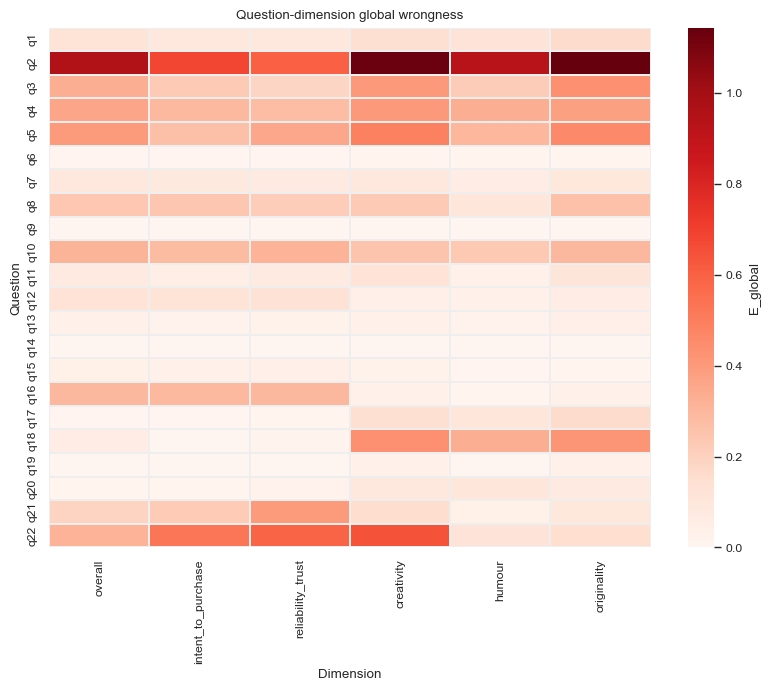

In [25]:
heat = wrongness.pivot_table(index="question_id", columns="dimension", values="E_global", aggfunc="mean")
heat = heat.reindex(sorted(heat.index, key=lambda x: int(str(x)[1:])))
dimension_order = [d for d in ["overall", "intent_to_purchase", "reliability_trust", "creativity", "humour", "originality"] if d in heat.columns]
heat = heat[dimension_order]

fig, ax = plt.subplots(figsize=(8.2, 7.0))
sns.heatmap(heat, cmap="Reds", linewidths=0.3, linecolor="#eeeeee", cbar_kws={"label": "E_global"}, ax=ax)
ax.set_xlabel("Dimension")
ax.set_ylabel("Question")
ax.set_title("Question-dimension global wrongness")
fig.tight_layout()
fig.savefig(FIG_DIR / "question_dimension_wrongness_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## Output files

The notebook writes tables and figures for the next draft.


In [26]:
question_summary = (
    wrongness.groupby(["question_id", "question_column", "question_block"])
    .agg(
        mean_wrong_rate=("wrong_rate", "mean"),
        mean_E_false=("E_false", "mean"),
        mean_E_global=("E_global", "mean"),
        max_E_global=("E_global", "max"),
        mean_abs_corr=("abs_corr_with_output", "mean"),
        mean_reliability_index=("reliability_index", "mean"),
    )
    .reset_index()
    .sort_values("mean_E_global", ascending=False)
)

question_summary.to_csv(TABLE_DIR / "question_wrongness_summary.csv", index=False)

created = sorted([str(p.relative_to(OUTPUT_DIR)) for p in OUTPUT_DIR.rglob("*") if p.is_file()])
display(pd.DataFrame({"created": created}))


,created
0,figures/dimension_global_wrongness.png
1,figures/highest_global_wrongness.png
2,figures/most_reliable_question_signals.png
3,figures/question_dimension_wrongness_heatmap.png
4,tables/dimension_wrongness_summary.csv
5,tables/question_block_wrongness_summary.csv
6,tables/question_dimension_wrongness.csv
7,tables/question_wrongness_summary.csv
8,tables/wrongness_ablation_summary.csv
9,tables/wrongness_long_table.csv
